# HW12 - Forecasting: temporal split, baselines, and GRU

Ноутбук содержит обязательные эксперименты B1/B2/B3/R1 и сохраняет артефакты в `artifacts/`.

In [1]:
import json
import math
import random
from dataclasses import dataclass
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.preprocessing import StandardScaler
from torch.utils.data import Dataset, DataLoader

In [2]:
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed(42)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('device =', device)

ROOT = Path('.')
ARTIFACTS = ROOT / 'artifacts'
FIGURES = ARTIFACTS / 'figures'
ARTIFACTS.mkdir(exist_ok=True)
FIGURES.mkdir(parents=True, exist_ok=True)

device = cpu


shape: (4320, 2)
date range: 2025-01-01 00:00:00 -> 2025-06-29 23:00:00
missing: {'date': 0, 'target': 0}


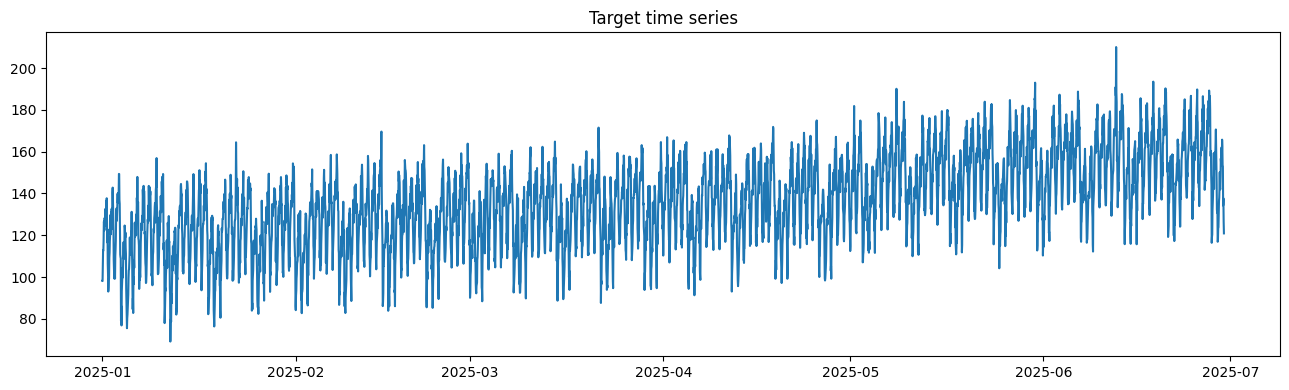

In [3]:
df = pd.read_csv('S12-hw-dataset.csv')
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values('date').reset_index(drop=True)

print('shape:', df.shape)
print('date range:', df['date'].min(), '->', df['date'].max())
print('missing:', df.isna().sum().to_dict())

plt.figure(figsize=(13, 4))
plt.plot(df['date'], df['target'])
plt.title('Target time series')
plt.tight_layout()
plt.show()

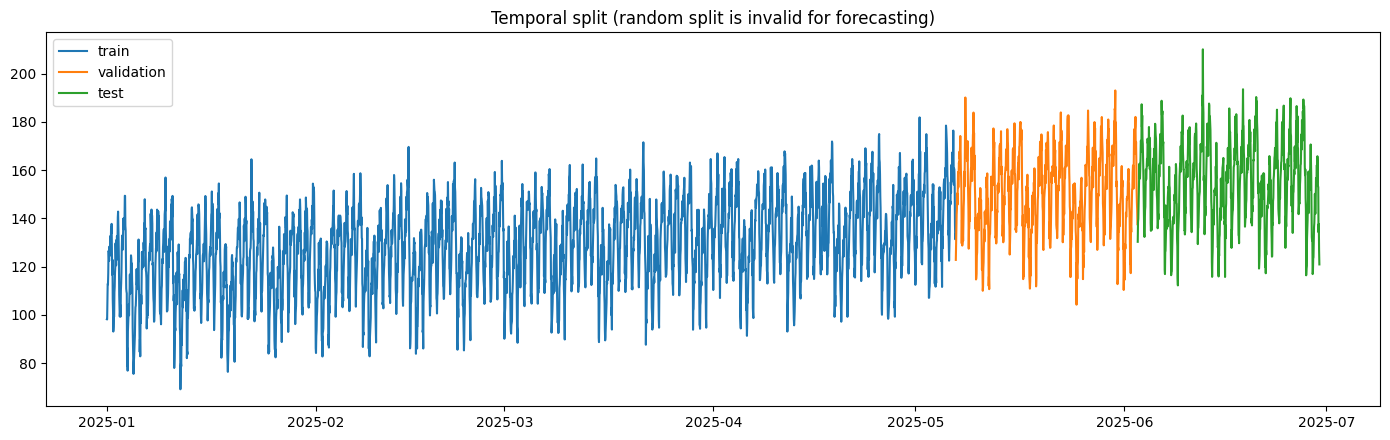

In [4]:
@dataclass
class SplitCfg:
    train_frac: float = 0.70
    val_frac: float = 0.15

cfg = SplitCfg()
n = len(df)
train_end = int(n * cfg.train_frac)
val_end = int(n * (cfg.train_frac + cfg.val_frac))

train_df = df.iloc[:train_end].copy()
val_df = df.iloc[train_end:val_end].copy()
test_df = df.iloc[val_end:].copy()

plt.figure(figsize=(14, 4.5))
plt.plot(train_df['date'], train_df['target'], label='train')
plt.plot(val_df['date'], val_df['target'], label='validation')
plt.plot(test_df['date'], test_df['target'], label='test')
plt.title('Temporal split (random split is invalid for forecasting)')
plt.legend()
plt.tight_layout()
plt.savefig('artifacts/figures/series_split.png', dpi=140)
plt.show()

In [ ]:
def rmse(y_true, y_pred):
    return float(math.sqrt(mean_squared_error(y_true, y_pred)))

def mape(y_true, y_pred):
    denom = np.clip(np.abs(y_true), 1e-8, None)
    return float(np.mean(np.abs((y_true - y_pred) / denom)) * 100)

def calc_metrics(y_true, y_pred):
    return {
        'mae': float(mean_absolute_error(y_true, y_pred)),
        'rmse': rmse(y_true, y_pred),
        'mape': mape(y_true, y_pred),
    }

def baseline_b2_moving_average(series: pd.Series, window: int = 7) -> pd.Series:
    # B2 baseline: one-step forecast by moving average over previous window points.
    return series.shift(1).rolling(window=window, min_periods=window).mean()

def fit_feature_scaler(train_features: pd.DataFrame) -> StandardScaler:
    scaler = StandardScaler()
    scaler.fit(train_features)
    return scaler

def transform_features_with_scaler(scaler: StandardScaler, features: pd.DataFrame) -> np.ndarray:
    return scaler.transform(features)

feat = df.copy()
feat['lag_1'] = feat['target'].shift(1)
feat['lag_7'] = feat['target'].shift(7)
feat['lag_14'] = feat['target'].shift(14)
feat['b2_ma_7'] = baseline_b2_moving_average(feat['target'], window=7)
feat['rolling_mean_7'] = feat['b2_ma_7']
feat['rolling_std_7'] = feat['target'].shift(1).rolling(7).std()
feat['day_of_week'] = feat['date'].dt.dayofweek
feat = feat.dropna().reset_index(drop=True)

train_end_date = train_df['date'].max()
val_end_date = val_df['date'].max()
feat_train = feat[feat['date'] <= train_end_date].copy()
feat_val = feat[(feat['date'] > train_end_date) & (feat['date'] <= val_end_date)].copy()
feat_test = feat[feat['date'] > val_end_date].copy()

val_true = feat_val['target'].to_numpy()
b1_val_pred = feat_val['lag_1'].to_numpy()
b2_val_pred = feat_val['b2_ma_7'].to_numpy()

b1_val = calc_metrics(val_true, b1_val_pred)
b2_val = calc_metrics(val_true, b2_val_pred)

feature_cols = ['lag_1', 'lag_7', 'lag_14', 'rolling_mean_7', 'rolling_std_7', 'day_of_week']
scaler_x = fit_feature_scaler(feat_train[feature_cols])
X_train = transform_features_with_scaler(scaler_x, feat_train[feature_cols])
X_val = transform_features_with_scaler(scaler_x, feat_val[feature_cols])
ridge = Ridge(alpha=1.0)
ridge.fit(X_train, feat_train['target'].to_numpy())
b3_val_pred = ridge.predict(X_val)
b3_val = calc_metrics(val_true, b3_val_pred)

print('B1:', b1_val)
print('B2:', b2_val)
print('B3:', b3_val)

B1: {'mae': 6.444814814814815, 'rmse': 8.20102295260389, 'mape': 4.39792166354992}
B2: {'mae': 12.702012786596118, 'rmse': 15.217644526713752, 'mape': 8.81686403093607}
B3: {'mae': 7.188729774210058, 'rmse': 8.732281856975053, 'mape': 4.796688920293988}


In [ ]:
window_size = 24
horizon = 1

def fit_target_scaler(train_part: pd.DataFrame) -> StandardScaler:
    scaler = StandardScaler()
    scaler.fit(train_part[['target']])
    return scaler

def transform_target_with_scaler(scaler: StandardScaler, part: pd.DataFrame) -> np.ndarray:
    return scaler.transform(part[['target']]).astype(np.float32).ravel()

# Temporal-series setup: fit scaler on train only, then transform val/test with the same scaler.
scaler_target = fit_target_scaler(train_df)
train_scaled = transform_target_with_scaler(scaler_target, train_df)
val_scaled = transform_target_with_scaler(scaler_target, val_df)
test_scaled = transform_target_with_scaler(scaler_target, test_df)

def make_windows(series, dates, win, h=1):
    X, y, y_dates = [], [], []
    for i in range(len(series) - win - h + 1):
        X.append(series[i:i+win])
        y.append(series[i+win+h-1])
        y_dates.append(dates[i+win+h-1])
    return np.asarray(X, dtype=np.float32)[..., None], np.asarray(y, dtype=np.float32), np.asarray(y_dates)

X_train_w, y_train_w, _ = make_windows(train_scaled, train_df['date'].to_numpy(), window_size, horizon)
X_val_w, y_val_w, _ = make_windows(val_scaled, val_df['date'].to_numpy(), window_size, horizon)
X_test_w, y_test_w, test_dates_w = make_windows(test_scaled, test_df['date'].to_numpy(), window_size, horizon)

class SeqDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

# For time-series training we keep chronological order (shuffle=False).
train_loader = DataLoader(SeqDataset(X_train_w, y_train_w), batch_size=64, shuffle=False)
val_loader = DataLoader(SeqDataset(X_val_w, y_val_w), batch_size=128, shuffle=False)
test_loader = DataLoader(SeqDataset(X_test_w, y_test_w), batch_size=128, shuffle=False)

class GRUForecaster(nn.Module):
    def __init__(self, hidden_size=64):
        super().__init__()
        self.gru = nn.GRU(input_size=1, hidden_size=hidden_size, batch_first=True)
        self.head = nn.Linear(hidden_size, 1)

    def forward(self, x):
        out, _ = self.gru(x)
        return self.head(out[:, -1, :]).squeeze(-1)

@torch.no_grad()
def predict_scaled(model, loader):
    model.eval()
    preds, true = [], []
    for xb, yb in loader:
        xb = xb.to(device)
        preds.append(model(xb).detach().cpu().numpy())
        true.append(yb.numpy())
    return np.concatenate(preds), np.concatenate(true)

def eval_original(model, loader):
    p, t = predict_scaled(model, loader)
    p = scaler_target.inverse_transform(p.reshape(-1, 1)).ravel()
    t = scaler_target.inverse_transform(t.reshape(-1, 1)).ravel()
    return calc_metrics(t, p), p, t

model = GRUForecaster(hidden_size=64).to(device)
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

history = {'train_loss': [], 'val_mae': []}
best_state = None
best_val_mae = float('inf')
wait = 0
patience = 6

for epoch in range(1, 31):
    model.train()
    losses = []
    for xb, yb in train_loader:
        xb = xb.to(device)
        yb = yb.to(device)

        optimizer.zero_grad(set_to_none=True)
        loss = criterion(model(xb), yb)
        loss.backward()
        optimizer.step()
        losses.append(loss.item())

    val_m, _, _ = eval_original(model, val_loader)
    history['train_loss'].append(float(np.mean(losses)))
    history['val_mae'].append(val_m['mae'])

    if val_m['mae'] < best_val_mae:
        best_val_mae = val_m['mae']
        best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
        wait = 0
    else:
        wait += 1
        if wait >= patience:
            break

model.load_state_dict(best_state)
r1_val, _, _ = eval_original(model, val_loader)
print('R1:', r1_val)

R1: {'mae': 5.299040794372559, 'rmse': 6.8972968846632625, 'mape': 3.5521631240844727}


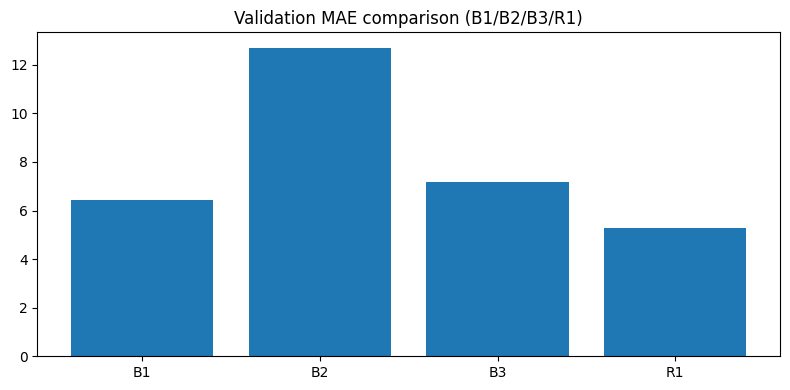

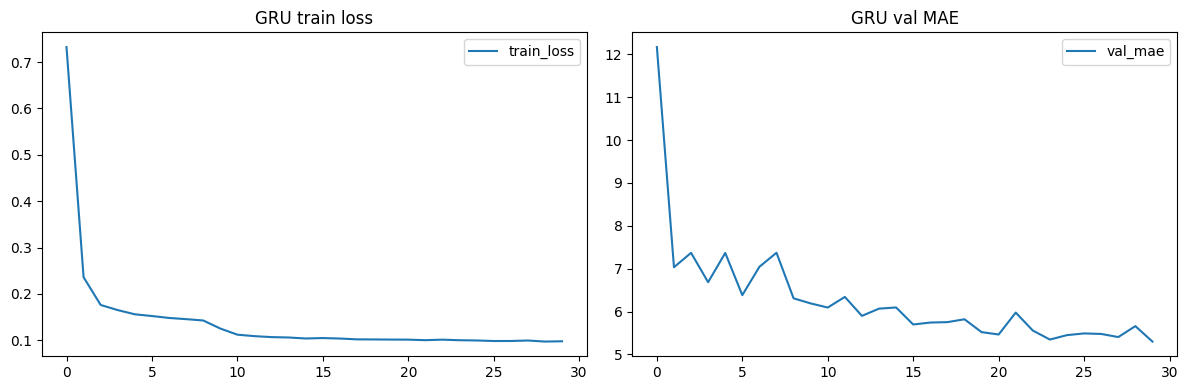

Best model by validation: R1
Final test metrics: {'mae': 6.075066089630127, 'rmse': 7.742526480974654, 'mape': 3.8961284160614014}


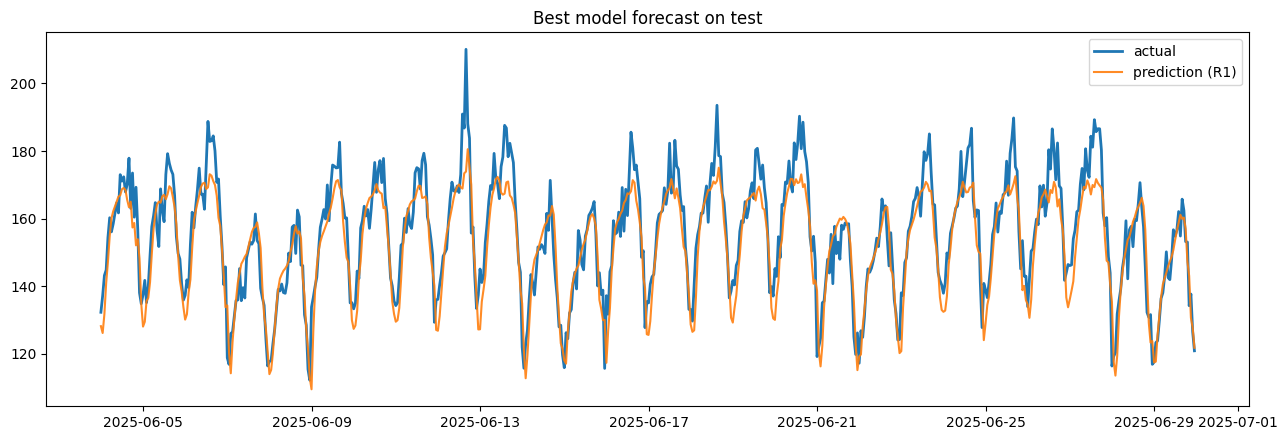

,experiment_id,task,dataset,seed,split_summary,window_size,horizon,model_summary,features_summary,scaler,optimizer,lr,epochs_trained,best_val_mae,best_val_rmse,best_val_mape,test_mae,test_rmse,test_mape,notes
0,B1,forecasting,S12-hw-dataset.csv,42,train:2025-01-01..2025-05-06;val:2025-05-07..2...,NaN,1,naive-last,lag_1,None,None,NaN,NaN,6.444815,8.201023,4.397922,NaN,NaN,NaN,
1,B2,forecasting,S12-hw-dataset.csv,42,train:2025-01-01..2025-05-06;val:2025-05-07..2...,7.0,1,moving-average,rolling_mean_7,None,None,NaN,NaN,12.702013,15.217645,8.816864,NaN,NaN,NaN,
2,B3,forecasting,S12-hw-dataset.csv,42,train:2025-01-01..2025-05-06;val:2025-05-07..2...,NaN,1,ridge-lag-features,lag_1+lag_7+lag_14+rolling_mean_7+rolling_std_...,StandardScaler(features),None,NaN,NaN,7.188730,8.732282,4.796689,NaN,NaN,NaN,
3,R1,forecasting,S12-hw-dataset.csv,42,train:2025-01-01..2025-05-06;val:2025-05-07..2...,24.0,1,gru-forecast,univariate target windows,StandardScaler(target),Adam,0.001,30.0,5.299041,6.897297,3.552163,6.075066,7.742526,3.896128,chosen_best


In [ ]:
val_cmp = pd.DataFrame([
    {'experiment_id': 'B1', 'model_summary': 'naive-last', 'val_mae': b1_val['mae'], 'val_rmse': b1_val['rmse'], 'val_mape': b1_val['mape']},
    {'experiment_id': 'B2', 'model_summary': 'moving-average', 'val_mae': b2_val['mae'], 'val_rmse': b2_val['rmse'], 'val_mape': b2_val['mape']},
    {'experiment_id': 'B3', 'model_summary': 'ridge-lag-features', 'val_mae': b3_val['mae'], 'val_rmse': b3_val['rmse'], 'val_mape': b3_val['mape']},
    {'experiment_id': 'R1', 'model_summary': 'gru-forecast', 'val_mae': r1_val['mae'], 'val_rmse': r1_val['rmse'], 'val_mape': r1_val['mape']},
])

plt.figure(figsize=(8, 4))
plt.bar(val_cmp['experiment_id'], val_cmp['val_mae'])
plt.title('Validation MAE comparison (B1/B2/B3/R1)')
plt.tight_layout()
plt.savefig('artifacts/figures/baselines_compare.png', dpi=140)
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(history['train_loss'], label='train_loss')
axes[0].set_title('GRU train loss')
axes[0].legend()
axes[1].plot(history['val_mae'], label='val_mae')
axes[1].set_title('GRU val MAE')
axes[1].legend()
plt.tight_layout()
plt.savefig('artifacts/figures/gru_learning_curves.png', dpi=140)
plt.show()

best_id = val_cmp.sort_values('val_mae').iloc[0]['experiment_id']
print('Best model by validation:', best_id)

b_test_true = feat_test['target'].to_numpy()
b1_test_pred = feat_test['lag_1'].to_numpy()
b2_test_pred = feat_test['b2_ma_7'].to_numpy()
b3_test_pred = ridge.predict(transform_features_with_scaler(scaler_x, feat_test[feature_cols]))

if best_id == 'B1':
    test_dates = feat_test['date'].to_numpy()
    test_true = b_test_true
    test_pred = b1_test_pred
elif best_id == 'B2':
    test_dates = feat_test['date'].to_numpy()
    test_true = b_test_true
    test_pred = b2_test_pred
elif best_id == 'B3':
    test_dates = feat_test['date'].to_numpy()
    test_true = b_test_true
    test_pred = b3_test_pred
else:
    test_scaled_pred, test_scaled_true = predict_scaled(model, test_loader)
    test_dates = test_dates_w
    test_true = scaler_target.inverse_transform(test_scaled_true.reshape(-1, 1)).ravel()
    test_pred = scaler_target.inverse_transform(test_scaled_pred.reshape(-1, 1)).ravel()

test_metrics = calc_metrics(test_true, test_pred)
print('Final test metrics:', test_metrics)

plt.figure(figsize=(13, 4.5))
plt.plot(pd.to_datetime(test_dates), test_true, label='actual', linewidth=2)
plt.plot(pd.to_datetime(test_dates), test_pred, label=f'prediction ({best_id})', alpha=0.9)
plt.title('Best model forecast on test')
plt.legend()
plt.tight_layout()
plt.savefig('artifacts/figures/best_forecast_test.png', dpi=140)
plt.show()

torch.save(model.state_dict(), 'artifacts/best_gru.pt')
best_gru_config = {
    'model': 'GRUForecaster',
    'window_size': window_size,
    'horizon': horizon,
    'hidden_size': 64,
    'lr': 1e-3,
    'epochs_trained': len(history['train_loss']),
    'seed': 42,
    'normalization': {
        'target_scaler': {
            'type': 'StandardScaler',
            'fit_on': 'train_only',
            'transform_on': ['train', 'validation', 'test'],
            'inverse_transform_for_metrics': True
        },
        'feature_scaler': {
            'type': 'StandardScaler',
            'fit_on': 'train_only',
            'transform_on': ['train', 'validation', 'test'],
            'applies_to': feature_cols
        }
    }
}
with open('artifacts/best_gru_config.json', 'w', encoding='utf-8') as f:
    json.dump(best_gru_config, f, indent=2, ensure_ascii=False)

split_summary = f"train:{train_df['date'].min().date()}..{train_df['date'].max().date()};val:{val_df['date'].min().date()}..{val_df['date'].max().date()};test:{test_df['date'].min().date()}..{test_df['date'].max().date()}"

rows = []
for _, r in val_cmp.iterrows():
    eid = r['experiment_id']
    rows.append({
        'experiment_id': eid,
        'task': 'forecasting',
        'dataset': 'S12-hw-dataset.csv',
        'seed': 42,
        'split_summary': split_summary,
        'window_size': int(window_size) if eid == 'R1' else (7 if eid == 'B2' else None),
        'horizon': 1,
        'model_summary': r['model_summary'],
        'features_summary': {'B1': 'lag_1', 'B2': 'explicit moving-average(7) over previous points', 'B3': 'lag_1+lag_7+lag_14+rolling_mean_7+rolling_std_7+day_of_week', 'R1': 'univariate target windows'}[eid],
        'scaler': {'B3': 'StandardScaler(features, fit_on_train_only)', 'R1': 'StandardScaler(target, fit_on_train_only)'}.get(eid),
        'optimizer': 'Adam' if eid == 'R1' else None,
        'lr': 1e-3 if eid == 'R1' else None,
        'epochs_trained': len(history['train_loss']) if eid == 'R1' else None,
        'best_val_mae': float(r['val_mae']),
        'best_val_rmse': float(r['val_rmse']),
        'best_val_mape': float(r['val_mape']),
        'test_mae': test_metrics['mae'] if eid == best_id else None,
        'test_rmse': test_metrics['rmse'] if eid == best_id else None,
        'test_mape': test_metrics['mape'] if eid == best_id else None,
        'notes': 'chosen_best' if eid == best_id else ''
    })

runs_df = pd.DataFrame(rows)
runs_df.to_csv('artifacts/runs.csv', index=False)
display(runs_df)